# Find the most similar Census cells in any other data with embeddings vector search

This tutorial demonstrates the experimental API in the Python `cellxgene_census` package to search Census embeddings using [TileDB-Vector-Search](https://github.com/TileDB-Inc/TileDB-Vector-Search) indexes. We will generate [scVI embeddings](https://docs.scvi-tools.org/en/1.0.0/tutorials/notebooks/api_overview.html) for some test cells, search the Census scVI embeddings for nearest neighbors, and use them to predict cell type and tissue of the test cells.

To reproduce this notebook, `pip install 'cellxgene_census[experimental]' scvi-tools` and obtain the [pbmc3k blood cells data](https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html) and scVI model:

**Contents**

1. Downloading data and Census scVI model.
2. Loading and embedding pbmc3k cells.
3. Search for similar Census cells.
4. Predicting cell metadata.

⚠️ Note that the Census RNA data includes duplicate cells present across multiple datasets. Duplicate cells can be filtered in or out using the cell metadata variable `is_primary_data` which is described in the [Census schema](https://github.com/chanzuckerberg/cellxgene-census/blob/main/docs/cellxgene_census_schema.md#repeated-data).

In [3]:
# Installation commands are taken from: https://docs.scvi-tools.org/en/latest/tutorials/notebooks/hub/cellxgene_census_model.html
# See also: https://chanzuckerberg.github.io/cellxgene-census/cellxgene_census_docsite_installation.html
!pip install --quiet scvi-colab
!pip install --quiet cellxgene-census
!pip install --quiet pybiomart # is gene chrY-related?
from scvi_colab import install
install()
!pip install owlready2 # ontology processing
!pip install --upgrade tiledb tiledb-vector-search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.5/789.5 kB 38.8 MB/s eta 0:00:00
  Attempting uninstall: tblib
    Found existing installation: tblib 3.0.0
    Uninstalling tblib-3.0.0:
      Successfully uninstalled tblib-3.0.0
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.0
    Uninstalling cloudpickle-3.1.0:
      Successfully uninstalled cloudpickle-3.1.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask 2024.8.2 requires cloudpickle>=3.0.0, but you have cloudpickle 2.2.1 which is incompatible.
distributed 2024.8.2 requires cloudpickle>=3.0.0, but you have cloudpickle 2.2.1 which is incompatible.


In [ ]:
# Import necessary libraries
import cellxgene_census
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import scvi
from owlready2 import *

## Downloading data and Census scVI model

Download the data first. This the 10X PBMC 3K dataset.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import anndata
import cellxgene_census
import cellxgene_census.experimental
import pandas as pd
import scanpy as sc
import scvi

CENSUS_VERSION = "2024-07-01"

Download the test data which will be used to look for their Census most similar cells. This is the test 10X PMBC dataset.

In [2]:
!mkdir -p data
!wget --no-check-certificate -q -O data/pbmc3k_filtered_gene_bc_matrices.tar.gz http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz
!tar -xzf data/pbmc3k_filtered_gene_bc_matrices.tar.gz -C data/

Now download the model corresponding to the census version used in the notebook.

First find S3 location of the model.

In [3]:
with cellxgene_census.open_soma(census_version=CENSUS_VERSION) as census:
    #census = cellxgene_census.open_soma(census_version=CENSUS_VERSION)

    scvi_info = cellxgene_census.experimental.get_embedding_metadata_by_name(
        embedding_name="scvi",
        organism="homo_sapiens",
        census_version=CENSUS_VERSION,
    )

scvi_info["model_link"]

's3://cellxgene-contrib-public/models/scvi/2024-07-01/homo_sapiens/model.pt'

Now use that path to download via HTTPs, make sure to update the URL if you change the Census version.

In [4]:
!mkdir -p scvi-human-2024-07-01
!wget --no-check-certificate -q -O scvi-human-2024-07-01/model.pt https://cellxgene-contrib-public.s3.us-west-2.amazonaws.com/models/scvi/2024-07-01/homo_sapiens/model.pt

## Loading and embedding pbmc3k cells

Load the pmbc3k cell data into an AnnData:

In [5]:
adata = sc.read_10x_mtx("data/filtered_gene_bc_matrices/hg19/", var_names="gene_ids")
adata.var["ensembl_id"] = adata.var.index
adata.obs["n_counts"] = adata.X.sum(axis=1)
adata.obs["joinid"] = list(range(adata.n_obs))
adata.obs["batch"] = "unassigned"

In [6]:
adata.var.head()

,gene_symbols,ensembl_id
ENSG00000243485,MIR1302-10,ENSG00000243485
ENSG00000237613,FAM138A,ENSG00000237613
ENSG00000186092,OR4F5,ENSG00000186092
ENSG00000238009,RP11-34P13.7,ENSG00000238009
ENSG00000239945,RP11-34P13.8,ENSG00000239945


Run them through the scVI forward pass and extract their latent representation (embedding):

In [7]:
scvi.model.SCVI.prepare_query_anndata(adata, "scvi-human-2024-07-01")
vae_q = scvi.model.SCVI.load_query_data(
    adata,
    "scvi-human-2024-07-01",
)

# This allows for a simple forward pass
vae_q.is_trained = True
latent = vae_q.get_latent_representation()
adata.obsm["scvi"] = latent

INFO     File scvi-human-2024-07-01/model.pt already downloaded                                                    
INFO     Found 54.675% reference vars in query data.                                                               
INFO     File scvi-human-2024-07-01/model.pt already downloaded                                                    


In [8]:
adata.var.head()

,gene_symbols,ensembl_id
ENSG00000000005,TNMD,ENSG00000000005
ENSG00000000971,CFH,ENSG00000000971
ENSG00000001167,NFYA,ENSG00000001167
ENSG00000001497,LAS1L,ENSG00000001497
ENSG00000001626,CFTR,ENSG00000001626


The scVI embedding vectors for each cell are now stored in the `scvi` obsm layer. Lastly, clean up the AnnData a little:

In [9]:
# filter out missing features
adata = adata[:, adata.var["gene_symbols"].notnull().values].copy()

duplicates = adata.var["gene_symbols"].duplicated()
if duplicates.any():
    duplicate_genes = adata.var["gene_symbols"][duplicates]
    print("Duplicate gene symbols found:")
    print(duplicate_genes)
else:
    print("No duplicate gene symbols found.")

adata.var.set_index("gene_symbols", inplace=True)
# assign placeholder cell_type and tissue_general labels
adata.var_names = adata.var["ensembl_id"]
adata.obs["cell_type"] = "Query - PBMC 10X"
adata.obs["tissue_general"] = "Query - PBMC 10X"

No duplicate gene symbols found.


In [10]:
adata.var.head()

,ensembl_id
ensembl_id,
ENSG00000000005,ENSG00000000005
ENSG00000000971,ENSG00000000971
ENSG00000001167,ENSG00000001167
ENSG00000001497,ENSG00000001497
ENSG00000001626,ENSG00000001626


And for visualization, compute leiden clusters on the scVI embeddings. These will come at handy later on.

2024-10-24 13:18:33.660889: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-24 13:18:33.688571: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-24 13:18:33.696718: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-24 13:18:35.856079: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


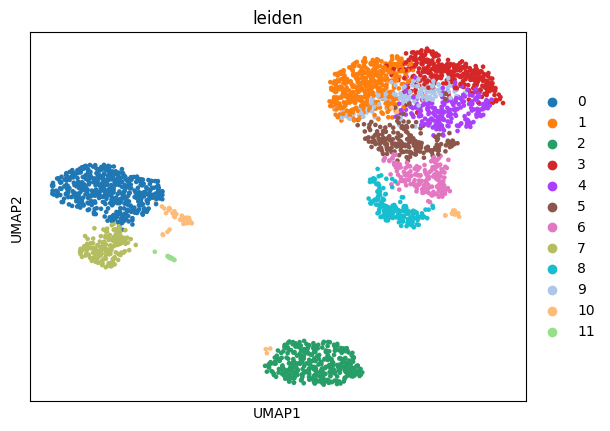

In [11]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep="scvi")
sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color="leiden")

## Search for similar Census cells

Use the CELLxGENE Census experimental API to search the vector index of scVI embeddings.

In [12]:
import tiledb
print(f"TileDB version: {tiledb.__version__}")

import tiledb.vector_search as vs
print(f"TileDB vector search version: {vs.__version__}")

TileDB version: 0.32.4
TileDB vector search version: 0.10.2


In [13]:
%%time
neighbors = cellxgene_census.experimental.find_nearest_obs(
    "scvi", "homo_sapiens", CENSUS_VERSION, query=adata, k=30, memory_GiB=8, nprobe=20
)

CPU times: user 1min 44s, sys: 1min, total: 2min 44s
Wall time: 3min 16s


This accessed the cell embeddings in the `scvi` obsm layer and searched the latent space for the *k* nearest neighbors (by Euclidean distance) among the Census cell embeddings, returning the distances and obs `soma_joinid`s (*k* for each query cell).

In [14]:
neighbors

NeighborObs(distances=array([[0.15405707, 0.16895759, 0.23857577, ..., 0.31588054, 0.31613642,
        0.31640556],
       [0.2901716 , 0.32429624, 0.34604436, ..., 0.5623445 , 0.56352055,
        0.56709284],
       [0.40463704, 0.41439027, 0.4177293 , ..., 0.5577937 , 0.56181353,
        0.5627155 ],
       ...,
       [0.19712517, 0.25228176, 0.2780037 , ..., 0.34790486, 0.3481129 ,
        0.3518862 ],
       [0.36992407, 0.3832988 , 0.39696047, ..., 0.5601517 , 0.56454164,
        0.5646584 ],
       [0.33078668, 0.3308513 , 0.357279  , ..., 0.52874595, 0.5310722 ,
        0.5326044 ]], dtype=float32), neighbor_ids=array([[53938900, 56894874, 53904832, ..., 35431931, 34956866, 53863941],
       [ 6276632, 18807209,  7251536, ..., 12705987, 11951694, 11980870],
       [16903285, 21674180, 50898826, ..., 35424173, 44145922, 36066801],
       ...,
       [36336282, 52999747, 53523979, ..., 54143971, 53062159, 46403244],
       [36217923, 46782331, 35719817, ..., 54091908, 46313955, 4

To explore these results, fetch an AnnData with each query cell's (single) nearest neighbor in scVI's latent space, including their embedding vectors:

In [15]:
with cellxgene_census.open_soma(census_version=CENSUS_VERSION) as census:
    neighbors_adata = cellxgene_census.get_anndata(
        census,
        "homo_sapiens",
        "RNA",
        obs_coords=sorted(neighbors.neighbor_ids[:, 0].tolist()),
        obs_embeddings=["scvi"],
        X_name="normalized",
        column_names={"obs": ["soma_joinid", "tissue", "tissue_general", "cell_type"]},
    )
neighbors_adata.var_names = neighbors_adata.var["feature_id"]

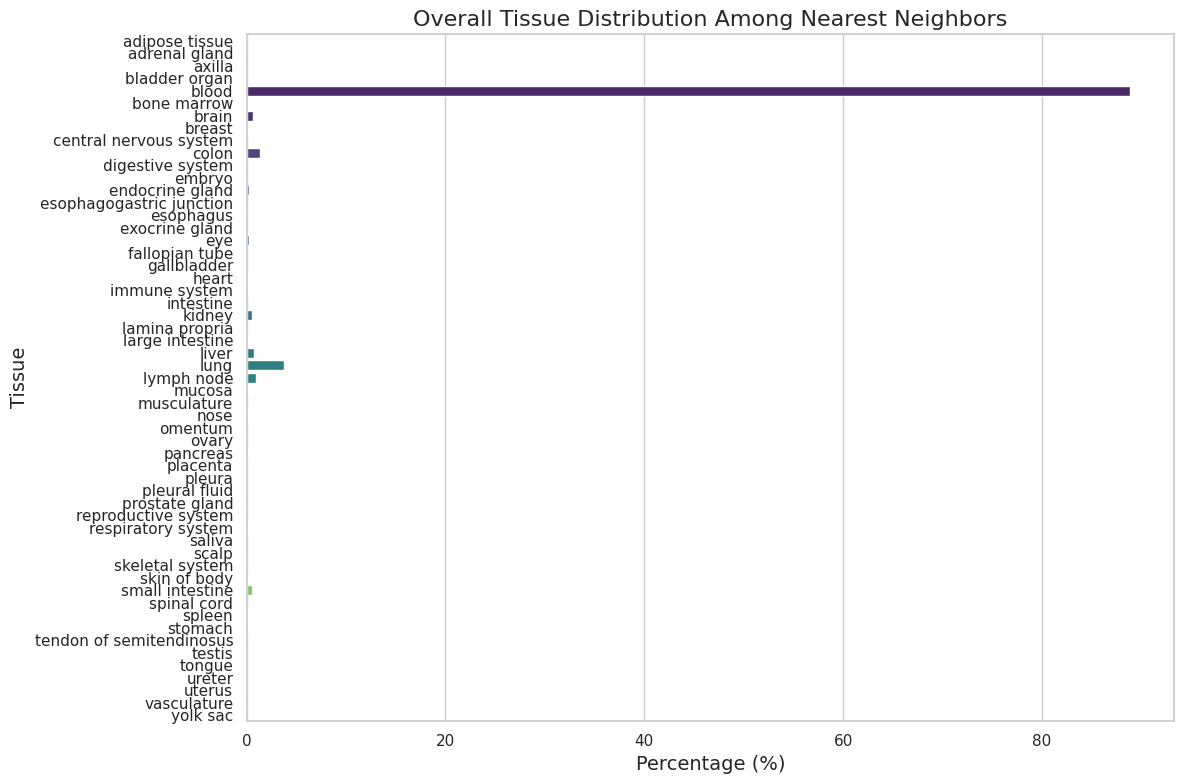

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the 'tissue_general' column from neighbors_adata
tissue_counts = neighbors_adata.obs['tissue_general'].value_counts()

# Calculate percentages
tissue_percentages = (tissue_counts / tissue_counts.sum()) * 100

# Create a DataFrame for better handling
tissue_df = tissue_percentages.reset_index()
tissue_df.columns = ['Tissue', 'Percentage']

# Display the DataFrame
print(tissue_df.head(10))

# Set the visual style
sns.set(style="whitegrid")

# Initialize the matplotlib figure
plt.figure(figsize=(12, 8))

# Create a bar plot
sns.barplot(x='Percentage', y='Tissue', data=tissue_df, palette='viridis')

# Add titles and labels
plt.title('Overall Tissue Distribution Among Nearest Neighbors', fontsize=16)
plt.xlabel('Percentage (%)', fontsize=14)
plt.ylabel('Tissue', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()

Make a UMAP visualization of these nearest neighbors:

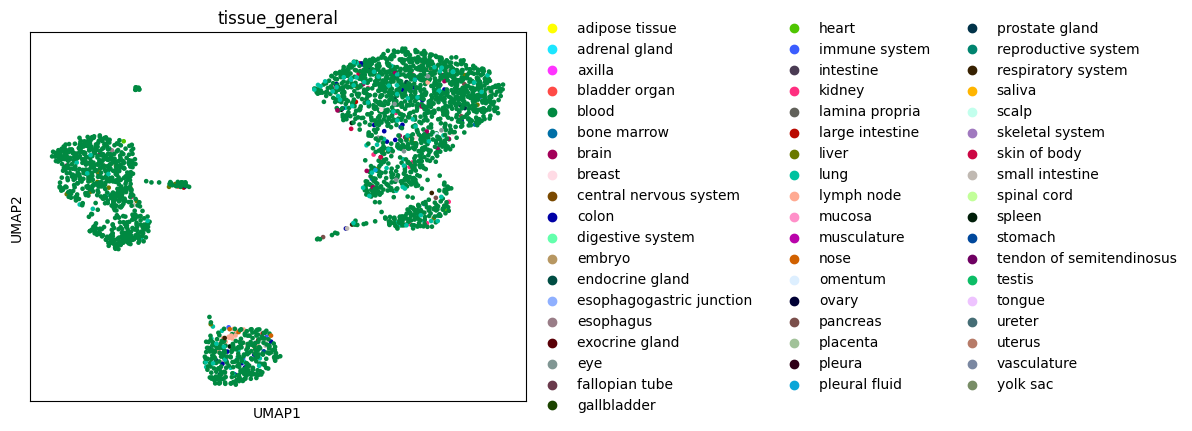

In [16]:
sc.pp.neighbors(neighbors_adata, n_neighbors=15, use_rep="scvi")
sc.tl.umap(neighbors_adata)
sc.pl.umap(neighbors_adata, color="tissue_general")

As expected, the nearest neighbors are largely Census blood cells, with some distinct cell type clusters.

Now display the pbmc3k query cells together with their Census nearest neighbors:

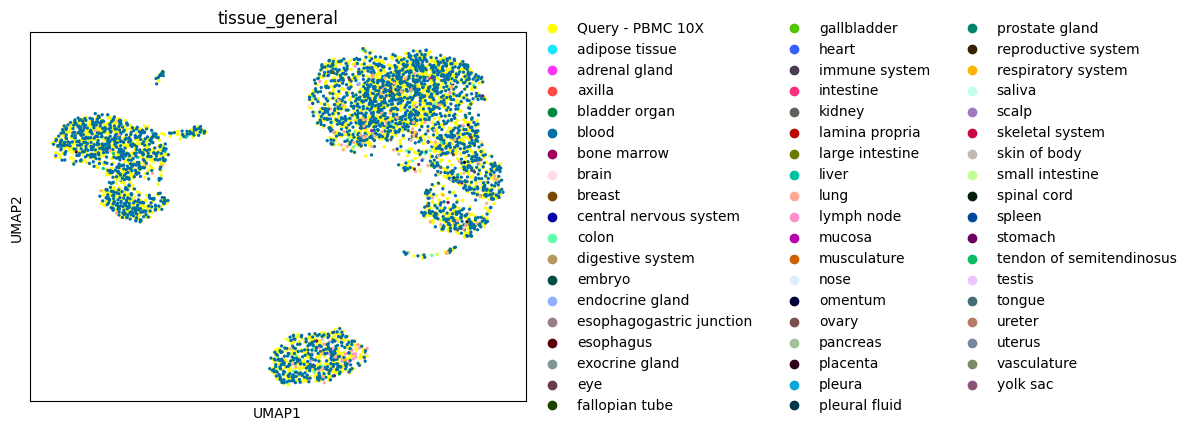

In [ ]:
adata_concat = anndata.concat([adata, neighbors_adata])
sc.pp.neighbors(adata_concat, n_neighbors=15, use_rep="scvi")
sc.tl.umap(adata_concat)
sc.pl.umap(adata_concat, color=["tissue_general"])

The neighbor clusters appear to correspond to cell type heterogeneity also present in the query.

## Predicting cell metadata

The experimental API also has a method to predict metadata attributes of the query cells, like `tissue_general` and `cell_type`, based on the Census nearest neighbors.

In [20]:
predictions = cellxgene_census.experimental.predict_obs_metadata(
    "homo_sapiens", CENSUS_VERSION, neighbors, ["tissue_general", "cell_type"]
)
predictions

,tissue_general,tissue_general_confidence,cell_type,cell_type_confidence
0,blood,0.866667,"CD4-positive, alpha-beta T cell",0.366667
1,lymph node,0.366667,B cell,0.433333
2,blood,0.966667,"central memory CD4-positive, alpha-beta T cell",0.266667
3,blood,0.900000,classical monocyte,0.733333
4,blood,0.900000,natural killer cell,0.633333
...,...,...,...,...
2695,blood,0.800000,classical monocyte,0.600000
2696,immune system,0.366667,plasmablast,0.566667
2697,blood,0.966667,B cell,0.633333
2698,blood,0.866667,B cell,0.600000


Unlike the above visualizations of *single* nearest neighbors, these predictions are informed by each query cell's *k*=30 neighbors, with an attached confidence score.

These predictions can be added to the original AnnData object for visualization.

In [21]:
predictions.index = adata.obs.index
predictions = predictions.rename(columns={"cell_type": "predicted_cell_type"})
adata.obs = pd.concat([adata.obs, predictions], axis=1)

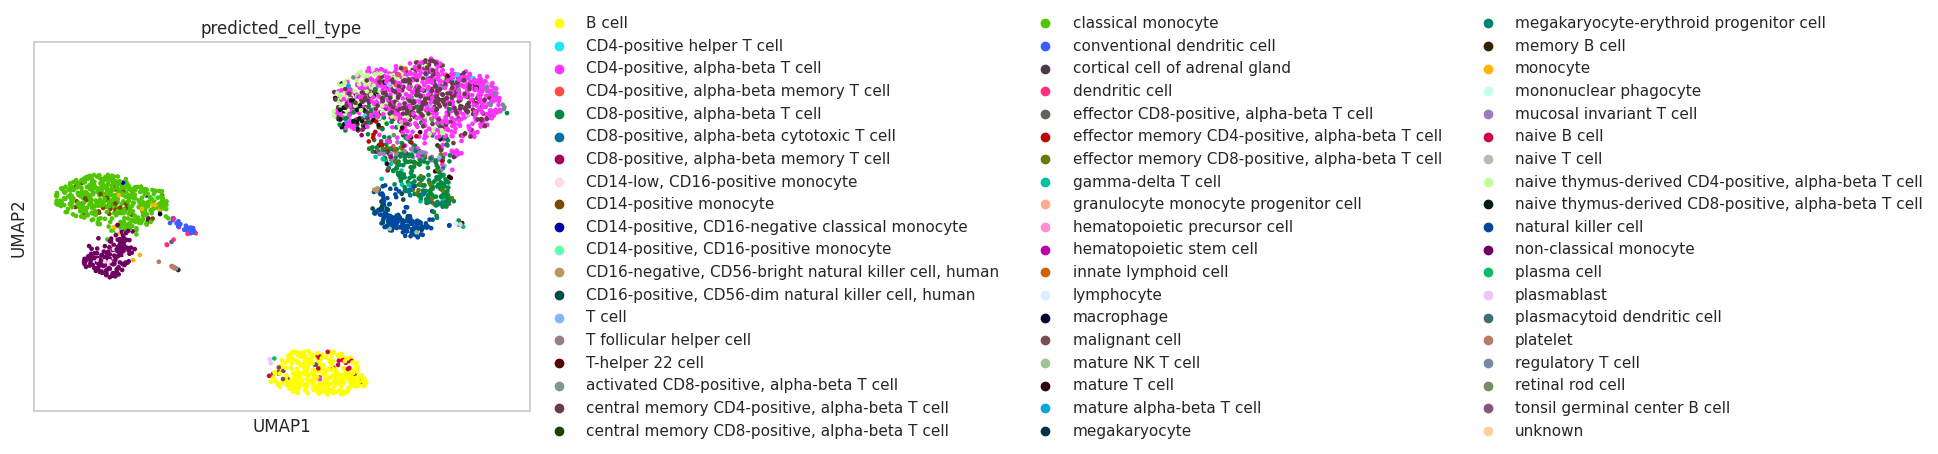

In [22]:
sc.pl.umap(adata, color="predicted_cell_type")

Now the leiden clusters calculated at the beginning can be annotated by popular vote, whereby each cluster gets assigned the most common predicted cell type from the previous step.

In [23]:
adata.obs["predicted_consolidated_cell_type"] = ""
for leiden_cluster in adata.obs["leiden"].drop_duplicates():
    most_popular_type = (
        adata.obs.loc[adata.obs["leiden"] == leiden_cluster,].value_counts("predicted_cell_type").index[0]
    )
    adata.obs.loc[adata.obs["leiden"] == leiden_cluster, "predicted_consolidated_cell_type"] = most_popular_type

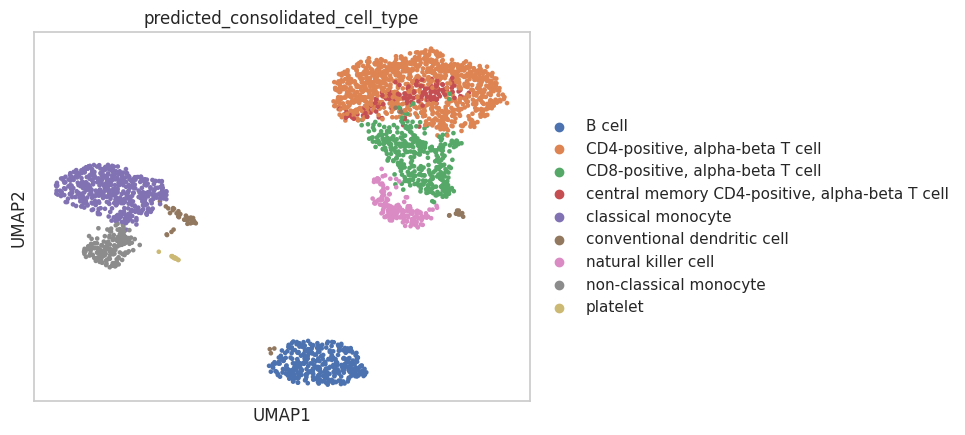

In [24]:
sc.pl.umap(adata, color="predicted_consolidated_cell_type")